# Reviewer sensitivity analysis: treating observed covariates as unobserved

## Question addressed

The reviewer requested a real-data sensitivity analysis that removes observed baseline
covariates from $X$, treats the removed variables as pseudo-unobserved confounders, and
reruns the proposed and comparison estimators under several reduced $X$ sets.

This notebook implements that analysis end to end on the frozen RHC data.

## Design

We avoid an arbitrary collection of hand-picked deletions and use three complementary,
pre-specified stress-test families:

1. **A/Y-predictive nested omission.** Rank all 49 meaningful raw baseline-variable
   blocks by their joint treatment/outcome predictive strength and omit the top 1, 2,
   3, 4, 5, 10, 15, 20, 25, 30, 35, 40, and 45.
2. **Proxy-predictive nested omission.** Separately rank the same 49 raw-variable
   blocks by their joint conditional predictive relevance for the four selected proxies
   and omit the top 1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, and 45.
3. **Union stress omission.** As the final and most aggressive stress test, jointly omit
   the union of the A/Y-predictive top 45 and the proxy-predictive top 45 sets.

The ranking uses standardized regularized coefficients and is used only to define the
sensitivity scenarios—not to tune any treatment-effect estimator. For transparency, the
notebook prints all selected variables and their treatment, outcome, and proxy scores.


In [1]:
"""Reproducible RHC experiments for Tables 8--10 and 13--14.

The neural estimators implement the two bridge moment equations for both
treatment arms.  Point estimates and standard errors are based on two-fold
cross-fitted doubly robust scores (Definition 5 and Theorem 33 of the paper).
"""

from __future__ import annotations

import json
import os
import random
from dataclasses import asdict, dataclass
from functools import lru_cache
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from linearmodels.iv import IV2SLS
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler


torch.set_num_threads(max(1, int(os.getenv("MINIMAX_TORCH_THREADS", "1"))))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DATA_PATH = None  # raw data are embedded below
PROXY_NAMES = ("pafi1", "paco21", "ph1", "hema1")
PROXY_SCHEMES = tuple(
    (tuple(z_pair), tuple(name for name in PROXY_NAMES if name not in z_pair))
    for z_pair in combinations(PROXY_NAMES, 2)
)

# These variables are identifiers, dates, or outcomes measured after admission.
NON_BASELINE = {
    "Unnamed: 0", "ptid", "sadmdte", "dschdte", "dthdte", "lstctdte",
    # `surv2md1` is the baseline SUPPORT survival prediction; `death` is an
    # observed post-admission outcome and must not be adjusted for.
    "t3d30", "death", "swang1", "dth30",
}


@dataclass(frozen=True)
class RHCConfig:
    scheme_id: int = 1
    width: int = 256
    hidden_layers: int = 3
    epochs: int = 500
    batch_size: int = 256
    learning_rate: float = 1e-3
    seed: int = 20260217
    folds: int = 2
    lambda_stab: float = 1.0
    gamma_stab: float = 5.0


class BridgeNet(nn.Module):
    def __init__(self, input_dim: int, width: int, hidden_layers: int, positive: bool):
        super().__init__()
        if hidden_layers < 1:
            raise ValueError("hidden_layers must be positive")
        dimensions = [input_dim]
        for layer in range(hidden_layers):
            dimensions.append(width if layer == 0 else max(16, width // 2))
        self.hidden = nn.ModuleList(
            nn.Linear(dimensions[i], dimensions[i + 1])
            for i in range(hidden_layers)
        )
        self.output = nn.Linear(dimensions[-1], 1)
        self.positive = positive

    def forward(self, value: torch.Tensor) -> torch.Tensor:
        for layer in self.hidden:
            value = F.relu(layer(value))
        value = self.output(value)
        if self.positive:
            value = F.softplus(value) + 1e-4
        return value


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def _standardize(values: np.ndarray) -> np.ndarray:
    values = values.astype(np.float32, copy=True)
    values[~np.isfinite(values)] = np.nan
    means = np.nanmean(values, axis=0)
    missing = np.where(np.isnan(values))
    values[missing] = np.take(means, missing[1])
    scale = values.std(axis=0, ddof=0)
    scale[scale < 1e-8] = 1.0
    return (values - values.mean(axis=0)) / scale


@lru_cache(maxsize=1)
def load_raw_data() -> pd.DataFrame:
    if not DATA_PATH.exists():
        raise FileNotFoundError(
            f"Missing frozen RHC snapshot: {DATA_PATH}. See README.md."
        )
    return pd.read_csv(DATA_PATH)


@lru_cache(maxsize=6)
def load_rhc(scheme_id: int):
    if not 1 <= scheme_id <= len(PROXY_SCHEMES):
        raise ValueError("scheme_id must be between 1 and 6")
    frame = load_raw_data().copy()
    z_names, w_names = PROXY_SCHEMES[scheme_id - 1]
    a = (
        frame["swang1"].astype(str).str.strip().str.upper().eq("RHC")
        .astype(np.float32).to_numpy()[:, None]
    )
    y = (
        frame["dth30"].astype(str).str.strip().str.upper().eq("NO")
        .astype(np.float32).to_numpy()[:, None]
    )
    excluded = NON_BASELINE | set(z_names) | set(w_names)
    x_frame = frame.drop(columns=[c for c in excluded if c in frame], errors="ignore")
    numeric = x_frame.select_dtypes(include=[np.number]).columns.tolist()
    categorical = [c for c in x_frame.columns if c not in numeric]
    x_frame = pd.get_dummies(x_frame, columns=categorical, drop_first=True, dtype=float)
    x_frame = x_frame.replace([np.inf, -np.inf], np.nan)
    x_frame = x_frame.fillna(x_frame.mean())
    nonconstant = x_frame.std(axis=0, ddof=0) > 1e-8
    x_frame = x_frame.loc[:, nonconstant]
    scaler = StandardScaler()
    x = scaler.fit_transform(x_frame.to_numpy(dtype=float)).astype(np.float32)
    z = _standardize(frame[list(z_names)].to_numpy(dtype=float))
    w = _standardize(frame[list(w_names)].to_numpy(dtype=float))
    return x, z, w, a, y, tuple(x_frame.columns), z_names, w_names


def rbf_gram(value: torch.Tensor) -> torch.Tensor:
    distance = torch.cdist(value, value).square()
    with torch.no_grad():
        upper = distance[torch.triu(torch.ones_like(distance, dtype=torch.bool), diagonal=1)]
        upper = upper[upper > 0]
        bandwidth = torch.median(upper) if upper.numel() else value.new_tensor(1.0)
        bandwidth = bandwidth.clamp(min=1e-8)
    return torch.exp(-distance / (2.0 * bandwidth))


def _moment_loss(
    residual: torch.Tensor,
    critic: torch.Tensor,
    kind: str,
    stabilized: bool,
    lambda_stab: float,
    gamma_stab: float,
) -> torch.Tensor:
    n = residual.shape[0]
    if kind == "h":
        gram = rbf_gram(critic)
        if not stabilized:
            return (residual.T @ gram @ residual).squeeze() / n**2
        identity = torch.eye(n, device=gram.device, dtype=gram.dtype)
        weighted = gram @ torch.linalg.solve(
            gamma_stab * identity + lambda_stab * gram, residual
        )
        return (residual.T @ weighted).squeeze() / n**2
    # The action-bridge critic H' uses a linear kernel.  Working with its
    # explicit features is faster and is exactly Equation (20)/(38).
    features = torch.cat([torch.ones_like(critic[:, :1]), critic], dim=1)
    moment = (features * residual).mean(dim=0, keepdim=True).T
    if not stabilized:
        return moment.square().sum()
    covariance = features.T @ features / n
    identity = torch.eye(covariance.shape[0], device=features.device, dtype=features.dtype)
    return (moment.T @ torch.linalg.solve(
        gamma_stab * identity + lambda_stab * covariance, moment
    )).squeeze()


def fit_bridge(
    config: RHCConfig,
    x: torch.Tensor,
    z: torch.Tensor,
    w: torch.Tensor,
    a: torch.Tensor,
    y: torch.Tensor,
    arm: int,
    kind: str,
    stabilized: bool,
    seed: int,
) -> nn.Module:
    set_seed(seed)
    source = w if kind == "h" else z
    model = BridgeNet(
        source.shape[1] + x.shape[1], config.width, config.hidden_layers,
        positive=(kind == "q"),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    n = len(x)
    for _ in range(config.epochs):
        permutation = torch.randperm(n)
        for start in range(0, n, config.batch_size):
            index = permutation[start : start + config.batch_size]
            if len(index) < 8:
                continue
            xb, zb, wb, ab, yb = x[index], z[index], w[index], a[index], y[index]
            mask = (ab == float(arm)).float()
            if kind == "h":
                prediction = model(torch.cat([wb, xb], dim=1))
                residual = mask * (yb - prediction)
                critic = torch.cat([zb, xb], dim=1)
            else:
                prediction = model(torch.cat([zb, xb], dim=1))
                residual = mask * prediction - 1.0
                critic = torch.cat([wb, xb], dim=1)
            loss = _moment_loss(
                residual, critic, kind, stabilized,
                config.lambda_stab, config.gamma_stab,
            )
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimizer.step()
    return model.eval()


def _fit_fold(config: RHCConfig, train, stabilized: bool, fold: int):
    x, z, w, a, y = train
    models = {}
    for arm in (0, 1):
        for offset, kind in enumerate(("h", "q")):
            seed = config.seed + 10_000 * int(stabilized) + 1_000 * fold + 10 * arm + offset
            models[(kind, arm)] = fit_bridge(
                config, x, z, w, a, y, arm, kind, stabilized, seed
            )
    return models


def _score(models, data):
    x, z, w, a, y = data
    with torch.no_grad():
        wx = torch.cat([w, x], dim=1)
        zx = torch.cat([z, x], dim=1)
        h0, h1 = models[("h", 0)](wx), models[("h", 1)](wx)
        q0, q1 = models[("q", 0)](zx), models[("q", 1)](zx)
        score = h1 - h0 + a * q1 * (y - h1) - (1.0 - a) * q0 * (y - h0)
    return score[:, 0].cpu().numpy(), {
        "q0_mean": float(q0.mean()), "q1_mean": float(q1.mean()),
        "q0_max": float(q0.max()), "q1_max": float(q1.max()),
    }


def _estimate_from_scores(scores: np.ndarray):
    point = float(np.mean(scores))
    se = float(np.std(scores, ddof=1) / np.sqrt(len(scores)))
    return {
        "point": point,
        "se": se,
        "ci_low": point - 1.96 * se,
        "ci_high": point + 1.96 * se,
    }

def _augmented_bases(x, z, w, y, specification: str):
    ones = np.ones((len(x), 1))
    correlation = np.nan_to_num(
        np.array([np.corrcoef(x[:, j], y[:, 0])[0, 1] for j in range(x.shape[1])])
    )
    top = x[:, np.argsort(np.abs(correlation))[-2:]]
    z_parts, w_parts = [ones, z, x], [ones, w, x]
    if specification in {"interaction", "both"}:
        z_parts.append((z[:, :, None] * top[:, None, :]).reshape(len(x), -1))
        w_parts.append((w[:, :, None] * top[:, None, :]).reshape(len(x), -1))
    if specification in {"quadratic", "both"}:
        z_parts.append(z**2)
        w_parts.append(w**2)
    return np.hstack(z_parts), np.hstack(w_parts), top


def linear_closed(scheme_id: int, specification: str = "original"):
    x, z, w, a, y, _, _, _ = load_rhc(scheme_id)
    x, z, w, a, y = [value.astype(np.float64) for value in (x, z, w, a, y)]
    bz, bw, _ = _augmented_bases(x, z, w, y, specification)
    phi = np.hstack([(1 - a) * bz, a * bz])
    psi = np.hstack([(1 - a) * bw, a * bw])
    tpsi = np.hstack([-bw, bw])
    moment = phi.T @ psi / len(x)
    target = (phi * y).mean(axis=0)
    theta = np.linalg.pinv(moment, rcond=1e-8) @ target
    point = float(tpsi.mean(axis=0) @ theta)
    # Full plug-in influence function: distribution of T h plus uncertainty
    # from estimating the bridge coefficients through E[phi(Y-psi theta)]=0.
    c = tpsi.mean(axis=0)
    alpha = np.linalg.pinv(moment.T, rcond=1e-8) @ c
    influence = tpsi @ theta - point + (phi @ alpha) * (y[:, 0] - psi @ theta)
    se = float(influence.std(ddof=1) / np.sqrt(len(x)))
    return {
        "point": point, "se": se,
        "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se,
    }


def linear_moment(scheme_id: int, specification: str = "original"):
    x, z, w, a, y, _, _, _ = load_rhc(scheme_id)
    x, z, w, a, y = [value.astype(np.float64) for value in (x, z, w, a, y)]
    _, _, top = _augmented_bases(x, z, w, y, specification)
    exogenous = np.hstack([np.ones((len(x), 1)), a, x])
    endogenous, instruments = [w], [z]
    if specification in {"interaction", "both"}:
        endogenous.append((w[:, :, None] * top[:, None, :]).reshape(len(x), -1))
        instruments.append((z[:, :, None] * top[:, None, :]).reshape(len(x), -1))
    if specification in {"quadratic", "both"}:
        endogenous.append(w**2)
        instruments.append(z**2)
    fitted = IV2SLS(
        dependent=y[:, 0], exog=exogenous,
        endog=np.hstack(endogenous), instruments=np.hstack(instruments),
    ).fit(cov_type="robust")
    point, se = float(fitted.params.iloc[1]), float(fitted.std_errors.iloc[1])
    return {
        "point": point, "se": se,
        "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se,
    }

In [2]:
import base64, gzip, hashlib, io

RHC_GZIP_BASE64 = (
    '...'
    'GCzw/wNtBz2AHGgjAA=='
)
RHC_CSV_SHA256 = '9ef4ab578be4b40ad5d97d3a7e08ffdc1f9f76aeeefee51b4996e4221556f8e8'

@lru_cache(maxsize=1)
def load_raw_data():
    raw_csv = gzip.decompress(base64.b64decode(RHC_GZIP_BASE64))
    if hashlib.sha256(raw_csv).hexdigest() != RHC_CSV_SHA256:
        raise RuntimeError("Embedded RHC data snapshot failed its SHA-256 integrity check")
    return pd.read_csv(io.BytesIO(raw_csv))

load_rhc.cache_clear()


In [3]:

from collections import OrderedDict

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold


ALL_PROXIES = list(PROXY_NAMES)
SCHEME_ID = 1
Z_NAMES, W_NAMES = PROXY_SCHEMES[SCHEME_ID - 1]


def raw_x_names():
    frame = load_raw_data()
    excluded = NON_BASELINE | set(ALL_PROXIES)
    return [name for name in frame.columns if name not in excluded]


def prepare_reduced_rhc(omit_raw=()):
    """Apply the paper preprocessing after removing complete raw-variable blocks."""
    frame = load_raw_data().copy()
    omit_raw = set(omit_raw)
    a = frame["swang1"].astype(str).str.strip().str.upper().eq("RHC").astype(np.float32).to_numpy()[:, None]
    y = frame["dth30"].astype(str).str.strip().str.upper().eq("NO").astype(np.float32).to_numpy()[:, None]
    excluded = NON_BASELINE | set(ALL_PROXIES) | omit_raw
    x_frame = frame.drop(columns=[name for name in excluded if name in frame], errors="ignore")
    numeric = x_frame.select_dtypes(include=[np.number]).columns.tolist()
    categorical = [name for name in x_frame.columns if name not in numeric]
    if x_frame.shape[1]:
        x_frame = pd.get_dummies(x_frame, columns=categorical, drop_first=True, dtype=float)
    x_frame = x_frame.replace([np.inf, -np.inf], np.nan).fillna(x_frame.mean())
    x_frame = x_frame.loc[:, x_frame.std(axis=0, ddof=0) > 1e-8]
    if x_frame.shape[1]:
        x = StandardScaler().fit_transform(x_frame.to_numpy(dtype=float)).astype(np.float32)
    else:
        x = np.empty((len(frame), 0), dtype=np.float32)
    z = _standardize(frame[list(Z_NAMES)].to_numpy(dtype=float))
    w = _standardize(frame[list(W_NAMES)].to_numpy(dtype=float))
    mapping = {
        raw: [i for i, encoded in enumerate(x_frame.columns)
              if encoded == raw or encoded.startswith(raw + "_")]
        for raw in raw_x_names() if raw not in omit_raw
    }
    return x, z, w, a, y, tuple(x_frame.columns), mapping


def covariate_ranking():
    x, z, w, a, y, columns, mapping = prepare_reduced_rhc(())
    treatment = LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs").fit(x, a[:, 0])
    outcome = LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs").fit(
        np.column_stack([a[:, 0], x]), y[:, 0]
    )
    proxies = np.column_stack([z, w])
    proxy_model = Ridge(alpha=10.0).fit(x, proxies)
    rows = []
    for raw, indices in mapping.items():
        if not indices:
            continue
        scale = np.sqrt(len(indices))
        treatment_strength = np.linalg.norm(treatment.coef_[0, indices]) / scale
        outcome_indices = 1 + np.asarray(indices)
        outcome_strength = np.linalg.norm(outcome.coef_[0, outcome_indices]) / scale
        proxy_strength = np.linalg.norm(proxy_model.coef_[:, indices]) / np.sqrt(4 * len(indices))
        rows.append({
            "variable": raw,
            "encoded_dims": len(indices),
            "treatment_strength": treatment_strength,
            "outcome_strength": outcome_strength,
            "joint_confounding_score": np.sqrt(treatment_strength * outcome_strength),
            "conditional_proxy_score": proxy_strength,
        })
    ranking = pd.DataFrame(rows)
    ranking["proxy_percentile"] = ranking["conditional_proxy_score"].rank(pct=True)
    return ranking.sort_values("joint_confounding_score", ascending=False).reset_index(drop=True)


RANKING = covariate_ranking()
ay_predictive_order = (
    RANKING.sort_values("joint_confounding_score", ascending=False)["variable"].tolist()
)
proxy_predictive_order = (
    RANKING.sort_values("conditional_proxy_score", ascending=False)["variable"].tolist()
)

STRESS_UNION = list(dict.fromkeys(
    ay_predictive_order[:45] + proxy_predictive_order[:45]
))
OMISSION_LEVELS = [1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 35, 40, 45]
SCENARIOS = OrderedDict(
    [("Full X (omit none)", [])]
    + [(f"A/Y-predictive omit top {k}", ay_predictive_order[:k]) for k in OMISSION_LEVELS]
    + [(f"Proxy-predictive omit top {k}", proxy_predictive_order[:k]) for k in OMISSION_LEVELS]
    + [("Stress omit: A/Y top 45 union Proxy top 45", STRESS_UNION)]
)


def effect_from_scores(scores):
    return _estimate_from_scores(np.asarray(scores, dtype=float))


def effect_tuple(item):
    return item["point"], item["se"], item["ci_low"], item["ci_high"]


def crossfit_ids(n, seed=RHCConfig().seed, folds=2):
    rng = np.random.default_rng(seed)
    permutation = rng.permutation(n)
    ids = np.empty(n, dtype=int)
    ids[permutation] = np.arange(n) % folds
    return ids


def moment_rms(features, residual):
    design = np.column_stack([np.ones(len(features)), features])
    moment = np.mean(design * residual[:, None], axis=0)
    return float(np.sqrt(np.mean(moment**2)))


def ess_ratio(weights):
    weights = np.asarray(weights, dtype=float)
    if len(weights) == 0 or np.sum(weights**2) == 0:
        return 0.0
    return float((weights.sum() ** 2 / np.sum(weights**2)) / len(weights))


def run_negative_control_neural(x_np, z_np, w_np, a_np, y_np, label, epochs=500):
    config = RHCConfig(scheme_id=1, width=256, hidden_layers=3, epochs=epochs)
    arrays = tuple(torch.from_numpy(value).float() for value in (x_np, z_np, w_np, a_np, y_np))
    n = len(x_np)
    fold_ids = crossfit_ids(n, config.seed, config.folds)
    effects, diagnostics = {}, {}
    for stabilized in (False, True):
        suffix = "(sta)" if stabilized else ""
        h0, h1, q0, q1 = [np.empty(n) for _ in range(4)]
        for fold in range(config.folds):
            train_index = np.flatnonzero(fold_ids != fold)
            test_index = np.flatnonzero(fold_ids == fold)
            train = tuple(value[train_index] for value in arrays)
            test = tuple(value[test_index] for value in arrays)
            models = _fit_fold(config, train, stabilized, fold)
            xt, zt, wt, at, yt = test
            with torch.no_grad():
                wx = torch.cat([wt, xt], dim=1)
                zx = torch.cat([zt, xt], dim=1)
                h0[test_index] = models[("h", 0)](wx)[:, 0].cpu().numpy()
                h1[test_index] = models[("h", 1)](wx)[:, 0].cpu().numpy()
                q0[test_index] = models[("q", 0)](zx)[:, 0].cpu().numpy()
                q1[test_index] = models[("q", 1)](zx)[:, 0].cpu().numpy()
        a, y = a_np[:, 0], y_np[:, 0]
        reg_score = h1 - h0
        ipw_score = a * q1 * y - (1.0 - a) * q0 * y
        dr_score = reg_score + a * q1 * (y - h1) - (1.0 - a) * q0 * (y - h0)
        effects[f"IPW{suffix}"] = effect_from_scores(ipw_score)
        effects[f"REG{suffix}"] = effect_from_scores(reg_score)
        effects[f"DR{suffix}"] = effect_from_scores(dr_score)
        h_moments = [
            moment_rms(np.column_stack([z_np, x_np]), (a == arm) * (y - (h1 if arm else h0)))
            for arm in (0, 1)
        ]
        q_moments = [
            moment_rms(np.column_stack([w_np, x_np]), (a == arm) * (q1 if arm else q0) - 1.0)
            for arm in (0, 1)
        ]
        active_q0, active_q1 = q0[a == 0], q1[a == 1]
        diagnostics[suffix or "non-sta"] = {
            "max_linear_moment_rms": max(h_moments + q_moments),
            "q_normalization_error": max(
                abs(np.mean((a == 0) * q0) - 1.0),
                abs(np.mean((a == 1) * q1) - 1.0),
            ),
            "minimum_q_ess_ratio": min(ess_ratio(active_q0), ess_ratio(active_q1)),
            "maximum_q": float(max(np.max(q0), np.max(q1))),
        }
    return effects, diagnostics, fold_ids


def run_standard_baselines(x, a, y, fold_ids):
    n = len(x)
    propensity, m0, m1 = np.empty(n), np.empty(n), np.empty(n)
    for fold in np.unique(fold_ids):
        train = fold_ids != fold
        test = ~train
        if x.shape[1]:
            propensity_model = LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs")
            propensity_model.fit(x[train], a[train])
            propensity[test] = propensity_model.predict_proba(x[test])[:, 1]
        else:
            propensity[test] = np.mean(a[train])
        for arm, target in ((0, m0), (1, m1)):
            arm_train = train & (a == arm)
            if x.shape[1]:
                outcome_model = LogisticRegression(C=1.0, max_iter=5000, solver="lbfgs")
                outcome_model.fit(x[arm_train], y[arm_train])
                target[test] = outcome_model.predict_proba(x[test])[:, 1]
            else:
                target[test] = np.mean(y[arm_train])
    propensity = np.clip(propensity, 0.01, 0.99)
    reg_score = m1 - m0
    ipw_score = a * y / propensity - (1.0 - a) * y / (1.0 - propensity)
    dr_score = reg_score + a * (y - m1) / propensity - (1.0 - a) * (y - m0) / (1.0 - propensity)
    p = float(np.mean(a))
    mean1, mean0 = float(np.mean(y[a == 1])), float(np.mean(y[a == 0]))
    unadjusted_point = mean1 - mean0
    unadjusted_if = a / p * (y - mean1) - (1.0 - a) / (1.0 - p) * (y - mean0)
    unadjusted = {
        "point": unadjusted_point,
        "se": float(np.std(unadjusted_if, ddof=1) / np.sqrt(n)),
    }
    unadjusted["ci_low"] = unadjusted["point"] - 1.96 * unadjusted["se"]
    unadjusted["ci_high"] = unadjusted["point"] + 1.96 * unadjusted["se"]
    return {
        "Plain IPW": effect_from_scores(ipw_score),
        "Plain REG": effect_from_scores(reg_score),
        "DR(no W,Z)": effect_from_scores(dr_score),
        "Unadjusted": unadjusted,
    }


def linear_closed_data(x, z, w, a, y, specification="original"):
    x, z, w, a, y = [value.astype(np.float64) for value in (x, z, w, a, y)]
    bz, bw, _ = _augmented_bases(x, z, w, y, specification)
    phi = np.hstack([(1 - a) * bz, a * bz])
    psi = np.hstack([(1 - a) * bw, a * bw])
    tpsi = np.hstack([-bw, bw])
    moment = phi.T @ psi / len(x)
    target = (phi * y).mean(axis=0)
    theta = np.linalg.pinv(moment, rcond=1e-8) @ target
    point = float(tpsi.mean(axis=0) @ theta)
    c = tpsi.mean(axis=0)
    alpha = np.linalg.pinv(moment.T, rcond=1e-8) @ c
    influence = tpsi @ theta - point + (phi @ alpha) * (y[:, 0] - psi @ theta)
    se = float(influence.std(ddof=1) / np.sqrt(len(x)))
    return {"point": point, "se": se, "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se}


def linear_moment_data(x, z, w, a, y, specification="original"):
    x, z, w, a, y = [value.astype(np.float64) for value in (x, z, w, a, y)]
    _, _, top = _augmented_bases(x, z, w, y, specification)
    exogenous = np.hstack([np.ones((len(x), 1)), a, x])
    endogenous, instruments = [w], [z]
    if specification in {"interaction", "both"}:
        endogenous.append((w[:, :, None] * top[:, None, :]).reshape(len(x), -1))
        instruments.append((z[:, :, None] * top[:, None, :]).reshape(len(x), -1))
    if specification in {"quadratic", "both"}:
        endogenous.append(w**2)
        instruments.append(z**2)
    fitted = IV2SLS(
        dependent=y[:, 0], exog=exogenous,
        endog=np.hstack(endogenous), instruments=np.hstack(instruments),
    ).fit(cov_type="robust")
    point, se = float(fitted.params.iloc[1]), float(fitted.std_errors.iloc[1])
    return {"point": point, "se": se, "ci_low": point - 1.96 * se, "ci_high": point + 1.96 * se}


def proxy_cv_r2(omit_raw):
    x, z, w, _, _, _, _ = prepare_reduced_rhc(omit_raw)
    proxies = np.column_stack([z, w])
    predictions = np.empty_like(proxies)
    splitter = KFold(n_splits=5, shuffle=True, random_state=20260217)
    for train, test in splitter.split(x):
        if x.shape[1]:
            model = Ridge(alpha=10.0).fit(x[train], proxies[train])
            predictions[test] = model.predict(x[test])
        else:
            predictions[test] = proxies[train].mean(axis=0)
    return float(r2_score(proxies, predictions, multioutput="variance_weighted"))


def effect_cell(item):
    return f"{item['point']:+.4f} ({item['se']:.5f})"


def ci_cell(item):
    return f"[{item['ci_low']:+.4f}, {item['ci_high']:+.4f}]"


In [4]:

from IPython.display import Markdown, display

display(Markdown("## Complete A/Y-predictive ranking used to define the scenarios"))
AY_RANKING_TABLE = RANKING.sort_values("joint_confounding_score", ascending=False).reset_index(drop=True).copy()
AY_RANKING_TABLE.insert(0, "A/Y predictive rank", np.arange(1, len(AY_RANKING_TABLE) + 1))
display(AY_RANKING_TABLE.style.format(precision=4))

display(Markdown("## Complete four-proxy-predictive ranking used to define the scenarios"))
PROXY_RANKING_TABLE = RANKING.sort_values("conditional_proxy_score", ascending=False).reset_index(drop=True).copy()
PROXY_RANKING_TABLE.insert(0, "Proxy predictive rank", np.arange(1, len(PROXY_RANKING_TABLE) + 1))
display(PROXY_RANKING_TABLE.style.format(precision=4))
display(Markdown(
    f"**Final stress omission:** the union of A/Y top 45 and Proxy top 45 contains "
    f"{len(STRESS_UNION)} of the 49 meaningful raw-variable blocks."
))

scenario_rows = []
full_proxy_r2 = proxy_cv_r2([])
for name, omitted in SCENARIOS.items():
    reduced = RANKING.set_index("variable").loc[omitted] if omitted else RANKING.iloc[0:0]
    _, _, _, _, _, encoded, _ = prepare_reduced_rhc(omitted)
    current_r2 = proxy_cv_r2(omitted)
    scenario_rows.append({
        "Scenario": name,
        "Omitted raw variables": ", ".join(omitted) if omitted else "None",
        "Omitted count": len(omitted),
        "Retained encoded X dimension": len(encoded),
        "Mean joint confounding score": float(reduced["joint_confounding_score"].mean()) if len(reduced) else 0.0,
        "Max conditional proxy score": float(reduced["conditional_proxy_score"].max()) if len(reduced) else 0.0,
        "Proxy CV R2": current_r2,
        "Proxy CV R2 loss vs full": full_proxy_r2 - current_r2,
    })
SCENARIO_DESIGN = pd.DataFrame(scenario_rows).set_index("Scenario")
display(Markdown("## Pre-specified X-omission scenarios"))
display(SCENARIO_DESIGN.style.format(precision=4))


## Complete A/Y-predictive ranking used to define the scenarios

,A/Y predictive rank,variable,encoded_dims,treatment_strength,outcome_strength,joint_confounding_score,conditional_proxy_score,proxy_percentile
0,1,surv2md1,1,0.6631,0.4953,0.5731,0.2455,0.9796
1,2,dnr1,1,0.2033,0.3207,0.2553,0.0215,0.2245
2,3,aps1,1,0.2025,0.1783,0.1900,0.2458,1.0000
3,4,cat1,8,0.2027,0.1355,0.1657,0.1088,0.9592
4,5,ca,2,0.1576,0.1361,0.1464,0.0459,0.6122
5,6,hrt1,1,0.2025,0.0977,0.1406,0.0492,0.7347
6,7,age,1,0.1794,0.0993,0.1335,0.0821,0.8776
7,8,neuro,1,0.1653,0.0952,0.1254,0.0485,0.7143
8,9,ninsclas,5,0.1315,0.1101,0.1203,0.0320,0.4286
9,10,transhx,1,0.1825,0.0776,0.1190,0.0409,0.5102


## Complete four-proxy-predictive ranking used to define the scenarios

,Proxy predictive rank,variable,encoded_dims,treatment_strength,outcome_strength,joint_confounding_score,conditional_proxy_score,proxy_percentile
0,1,aps1,1,0.2025,0.1783,0.1900,0.2458,1.0000
1,2,surv2md1,1,0.6631,0.4953,0.5731,0.2455,0.9796
2,3,cat1,8,0.2027,0.1355,0.1657,0.1088,0.9592
3,4,scoma1,1,0.2142,0.0651,0.1181,0.1055,0.9388
4,5,crea1,1,0.0929,0.0569,0.0727,0.0996,0.9184
5,6,alb1,1,0.0758,0.0516,0.0625,0.0844,0.8980
6,7,age,1,0.1794,0.0993,0.1335,0.0821,0.8776
7,8,pot1,1,0.1807,0.0115,0.0456,0.0718,0.8571
8,9,resp,1,0.1040,0.0766,0.0893,0.0696,0.8367
9,10,bili1,1,0.0320,0.2698,0.0929,0.0684,0.8163


**Final stress omission:** the union of A/Y top 45 and Proxy top 45 contains 49 of the 49 meaningful raw-variable blocks.

## Pre-specified X-omission scenarios

,Omitted raw variables,Omitted count,Retained encoded X dimension,Mean joint confounding score,Max conditional proxy score,Proxy CV R2,Proxy CV R2 loss vs full
Scenario,,,,,,,
Full X (omit none),None,0,68,0.0000,0.0000,0.2556,0.0000
A/Y-predictive omit top 1,surv2md1,1,67,0.5731,0.2455,0.2428,0.0128
A/Y-predictive omit top 2,"surv2md1, dnr1",2,66,0.4142,0.2455,0.2429,0.0127
A/Y-predictive omit top 3,"surv2md1, dnr1, aps1",3,65,0.3395,0.2458,0.2131,0.0425
A/Y-predictive omit top 4,"surv2md1, dnr1, aps1, cat1",4,57,0.2960,0.2458,0.1662,0.0893
A/Y-predictive omit top 5,"surv2md1, dnr1, aps1, cat1, ca",5,55,0.2661,0.2458,0.1665,0.0891
A/Y-predictive omit top 10,"surv2md1, dnr1, aps1, cat1, ca, hrt1, age, neuro, ninsclas, transhx",10,46,0.1969,0.2458,0.1609,0.0946
A/Y-predictive omit top 15,"surv2md1, dnr1, aps1, cat1, ca, hrt1, age, neuro, ninsclas, transhx, scoma1, cat2, hema, resp1, bili1",15,37,0.1670,0.2458,0.1537,0.1018
A/Y-predictive omit top 20,"surv2md1, dnr1, aps1, cat1, ca, hrt1, age, neuro, ninsclas, transhx, scoma1, cat2, hema, resp1, bili1, resp, urin1, psychhx, crea1, card",20,32,0.1449,0.2458,0.1277,0.1279


In [5]:

CORE_METHODS = [
    "IPW", "IPW(sta)", "REG", "REG(sta)", "DR", "DR(sta)",
    "Linear(closed-form)", "Linear(moment-based)",
    "Plain IPW", "Plain REG", "DR(no W,Z)", "Unadjusted",
]
SPECIFICATIONS = ("original", "interaction", "quadratic", "both")

ALL_RESULTS = OrderedDict()
ALL_DIAGNOSTICS = OrderedDict()
LINEAR_VARIANTS = OrderedDict()

for scenario, omitted in SCENARIOS.items():
    x, z, w, a, y, encoded_columns, _ = prepare_reduced_rhc(omitted)
    neural, diagnostics, fold_ids = run_negative_control_neural(x, z, w, a, y, scenario, epochs=500)
    standard = run_standard_baselines(x, a[:, 0], y[:, 0], fold_ids)
    core = dict(neural)
    core["Linear(closed-form)"] = linear_closed_data(x, z, w, a, y, "original")
    core["Linear(moment-based)"] = linear_moment_data(x, z, w, a, y, "original")
    core.update(standard)
    variants = {}
    for specification in SPECIFICATIONS:
        variants[f"Closed-{specification}"] = linear_closed_data(x, z, w, a, y, specification)
        variants[f"Moment-{specification}"] = linear_moment_data(x, z, w, a, y, specification)
    ALL_RESULTS[scenario] = core
    ALL_DIAGNOSTICS[scenario] = diagnostics
    LINEAR_VARIANTS[scenario] = variants



In [6]:

def omission_frame(columns, values_by_column):
    """Use the Table 13--14 layout, replacing permutation by an X omission."""
    index = pd.MultiIndex.from_product(
        [list(SCENARIOS), ["Treatment effects (SEs)", "95% CIs"]],
        names=["X omission", "Statistic"],
    )
    rows = []
    for row_number in range(len(SCENARIOS)):
        rows.append([effect_cell(values_by_column[column][row_number]) for column in columns])
        rows.append([ci_cell(values_by_column[column][row_number]) for column in columns])
    return pd.DataFrame(rows, index=index, columns=columns)


TABLE13_FIRST_COLUMNS = ["DR", "DR(sta)", "Linear(moment-based)"]
TABLE13_SECOND_COLUMNS = ["Linear(Interaction)", "Linear(Quadratic)", "Linear(Both)"]
TABLE14_FIRST_COLUMNS = ["DR", "DR(sta)", "Linear(closed-form)"]
TABLE14_SECOND_COLUMNS = ["Linear(Interaction)", "Linear(Quadratic)", "Linear(Both)"]

TABLE13_VALUES = {
    "DR": [ALL_RESULTS[scenario]["DR"] for scenario in SCENARIOS],
    "DR(sta)": [ALL_RESULTS[scenario]["DR(sta)"] for scenario in SCENARIOS],
    "Linear(moment-based)": [LINEAR_VARIANTS[scenario]["Moment-original"] for scenario in SCENARIOS],
    "Linear(Interaction)": [LINEAR_VARIANTS[scenario]["Moment-interaction"] for scenario in SCENARIOS],
    "Linear(Quadratic)": [LINEAR_VARIANTS[scenario]["Moment-quadratic"] for scenario in SCENARIOS],
    "Linear(Both)": [LINEAR_VARIANTS[scenario]["Moment-both"] for scenario in SCENARIOS],
}
TABLE14_VALUES = {
    "DR": [ALL_RESULTS[scenario]["DR"] for scenario in SCENARIOS],
    "DR(sta)": [ALL_RESULTS[scenario]["DR(sta)"] for scenario in SCENARIOS],
    "Linear(closed-form)": [LINEAR_VARIANTS[scenario]["Closed-original"] for scenario in SCENARIOS],
    "Linear(Interaction)": [LINEAR_VARIANTS[scenario]["Closed-interaction"] for scenario in SCENARIOS],
    "Linear(Quadratic)": [LINEAR_VARIANTS[scenario]["Closed-quadratic"] for scenario in SCENARIOS],
    "Linear(Both)": [LINEAR_VARIANTS[scenario]["Closed-both"] for scenario in SCENARIOS],
}

table13_first = omission_frame(TABLE13_FIRST_COLUMNS, TABLE13_VALUES)
table13_second = omission_frame(TABLE13_SECOND_COLUMNS, TABLE13_VALUES)
table14_first = omission_frame(TABLE14_FIRST_COLUMNS, TABLE14_VALUES)
table14_second = omission_frame(TABLE14_SECOND_COLUMNS, TABLE14_VALUES)

display(Markdown("# X-omission analogue of Table 13"))
display(Markdown("## Neural and original moment-based estimators"))
display(table13_first)
display(Markdown("## Moment-Based basis sensitivity"))
display(table13_second)

display(Markdown("# X-omission analogue of Table 14"))
display(Markdown("## Neural and original closed-form estimators"))
display(table14_first)
display(Markdown("## Closed-Form basis sensitivity"))
display(table14_second)

ALIGNED_VALUES = OrderedDict([
    ("DR", TABLE13_VALUES["DR"]),
    ("DR(sta)", TABLE13_VALUES["DR(sta)"]),
    ("T13 Linear(moment-based)", TABLE13_VALUES["Linear(moment-based)"]),
    ("T13 Linear(Interaction)", TABLE13_VALUES["Linear(Interaction)"]),
    ("T13 Linear(Quadratic)", TABLE13_VALUES["Linear(Quadratic)"]),
    ("T13 Linear(Both)", TABLE13_VALUES["Linear(Both)"]),
    ("T14 Linear(closed-form)", TABLE14_VALUES["Linear(closed-form)"]),
    ("T14 Linear(Interaction)", TABLE14_VALUES["Linear(Interaction)"]),
    ("T14 Linear(Quadratic)", TABLE14_VALUES["Linear(Quadratic)"]),
    ("T14 Linear(Both)", TABLE14_VALUES["Linear(Both)"]),
])
points = pd.DataFrame(
    {method: [item["point"] for item in values] for method, values in ALIGNED_VALUES.items()},
    index=list(SCENARIOS),
)
full_label = next(iter(SCENARIOS))
absolute_shift = points.drop(index=full_label).sub(points.loc[full_label], axis=1).abs()
proxy_rows = [name for name in absolute_shift.index if name.startswith("Proxy-predictive")]
stability = pd.DataFrame({
    "Max |shift|: proxy-predictive": absolute_shift.loc[proxy_rows].max(),
    "Mean |shift|: proxy-predictive": absolute_shift.loc[proxy_rows].mean(),
    "Max |shift|: all omissions": absolute_shift.max(),
    "Mean |shift|: all omissions": absolute_shift.mean(),
})
scenario_total = len(SCENARIOS)
robustness = pd.DataFrame({
    f"Negative point estimates (of {scenario_total})": {
        method: sum(item["point"] < 0 for item in values)
        for method, values in ALIGNED_VALUES.items()
    },
    f"95% CIs below zero (of {scenario_total})": {
        method: sum(item["ci_high"] < 0 for item in values)
        for method, values in ALIGNED_VALUES.items()
    },
    f"Sign agreement with Full X (of {scenario_total})": {
        method: sum(np.sign(item["point"]) == np.sign(values[0]["point"]) for item in values)
        for method, values in ALIGNED_VALUES.items()
    },
}).join(stability)

display(Markdown("# Table-13/14-aligned robustness summary"))
display(robustness.style.format(precision=4))
display(Markdown("# Absolute change from the full-X estimate"))
display(absolute_shift.style.format(precision=4))

diagnostic_rows = []
for scenario, diagnostics in ALL_DIAGNOSTICS.items():
    for fit, values in diagnostics.items():
        diagnostic_rows.append({"X omission": scenario, "Fit": fit, **values})
diagnostic_table = pd.DataFrame(diagnostic_rows).set_index(["X omission", "Fit"])
display(Markdown("# Negative-control bridge diagnostics"))
display(diagnostic_table.style.format(precision=4))

for table, expected_columns in (
    (table13_first, TABLE13_FIRST_COLUMNS),
    (table13_second, TABLE13_SECOND_COLUMNS),
    (table14_first, TABLE14_FIRST_COLUMNS),
    (table14_second, TABLE14_SECOND_COLUMNS),
):
    if list(table.columns) != expected_columns or len(table) != 2 * len(SCENARIOS):
        raise AssertionError("Table 13--14 layout mismatch")
nonnegative_dr_cis = [
    (method, scenario)
    for method in ("DR", "DR(sta)")
    for scenario, item in zip(SCENARIOS, TABLE13_VALUES[method])
    if item["ci_high"] >= 0
]
if nonnegative_dr_cis:
    display(Markdown(
        "**Inference conclusion:** The following proposed-DR 95% confidence intervals are not fully below zero: "
        + "; ".join(f"{method} under {scenario}" for method, scenario in nonnegative_dr_cis)
    ))
else:
    display(Markdown("**Inference conclusion:** All proposed-DR 95% confidence intervals are below zero."))


# X-omission analogue of Table 13

## Neural and original moment-based estimators

DR  \
X omission                                 Statistic                                     
Full X (omit none)                         Treatment effects (SEs)   -0.0528 (0.01194)   
                                           95% CIs                  [-0.0762, -0.0294]   
A/Y-predictive omit top 1                  Treatment effects (SEs)   -0.0577 (0.01073)   
                                           95% CIs                  [-0.0787, -0.0366]   
A/Y-predictive omit top 2                  Treatment effects (SEs)   -0.0472 (0.01064)   
                                           95% CIs                  [-0.0681, -0.0264]   
A/Y-predictive omit top 3                  Treatment effects (SEs)   -0.0774 (0.01223)   
                                           95% CIs                  [-0.1013, -0.0534]   
A/Y-predictive omit top 4                  Treatment effects (SEs)   -0.0731 (0.01272)   
                                           95% CIs                  [-0.0980, -0.0482]   
A/Y-predictive omit top 5                  Treatment effects (SEs)   -0.0658 (0.01120)   
                                           95% CIs                  [-0.0877, -0.0438]   
A/Y-predictive omit top 10                 Treatment effects (SEs)   -0.0589 (0.01255)   
                                           95% CIs                  [-0.0835, -0.0343]   
A/Y-predictive omit top 15                 Treatment effects (SEs)   -0.0488 (0.01187)   
                                           95% CIs                  [-0.0721, -0.0256]   
A/Y-predictive omit top 20                 Treatment effects (SEs)   -0.0593 (0.01210)   
                                           95% CIs                  [-0.0830, -0.0356]   
A/Y-predictive omit top 25                 Treatment effects (SEs)   -0.0405 (0.01159)   
                                           95% CIs                  [-0.0632, -0.0177]   
A/Y-predictive omit top 30                 Treatment effects (SEs)   -0.0524 (0.01220)   
                                           95% CIs                  [-0.0763, -0.0285]   
A/Y-predictive omit top 35                 Treatment effects (SEs)   -0.0426 (0.01239)   
                                           95% CIs                  [-0.0669, -0.0183]   
A/Y-predictive omit top 40                 Treatment effects (SEs)   -0.0448 (0.01230)   
                                           95% CIs                  [-0.0689, -0.0207]   
A/Y-predictive omit top 45                 Treatment effects (SEs)   -0.0588 (0.01258)   
                                           95% CIs                  [-0.0835, -0.0342]   
Proxy-predictive omit top 1                Treatment effects (SEs)   -0.0529 (0.01114)   
                                           95% CIs                  [-0.0747, -0.0310]   
Proxy-predictive omit top 2                Treatment effects (SEs)   -0.0907 (0.01108)   
                                           95% CIs                  [-0.1124, -0.0690]   
Proxy-predictive omit top 3                Treatment effects (SEs)   -0.0772 (0.01115)   
                                           95% CIs                  [-0.0990, -0.0553]   
Proxy-predictive omit top 4                Treatment effects (SEs)   -0.0888 (0.01536)   
                                           95% CIs                  [-0.1190, -0.0587]   
Proxy-predictive omit top 5                Treatment effects (SEs)   -0.0728 (0.01138)   
                                           95% CIs                  [-0.0951, -0.0504]   
Proxy-predictive omit top 10               Treatment effects (SEs)   -0.1019 (0.01105)   
                                           95% CIs                  [-0.1235, -0.0802]   
Proxy-predictive omit top 15               Treatment effects (SEs)   -0.0927 (0.01233)   
                                           95% CIs                  [-0.1169, -0.0686]   
Proxy-predictive omit top 20               Treatment effects (SEs)   -0.0856 (0.01232)   
                                  

## Moment-Based basis sensitivity

Linear(Interaction)  \
X omission                                 Statistic                                         
Full X (omit none)                         Treatment effects (SEs)       -0.0372 (0.07466)   
                                           95% CIs                      [-0.1835, +0.1091]   
A/Y-predictive omit top 1                  Treatment effects (SEs)       -0.0237 (0.06570)   
                                           95% CIs                      [-0.1524, +0.1051]   
A/Y-predictive omit top 2                  Treatment effects (SEs)       -0.0122 (0.06684)   
                                           95% CIs                      [-0.1432, +0.1188]   
A/Y-predictive omit top 3                  Treatment effects (SEs)       -0.0007 (0.10310)   
                                           95% CIs                      [-0.2028, +0.2014]   
A/Y-predictive omit top 4                  Treatment effects (SEs)       -0.0271 (0.04441)   
                                           95% CIs                      [-0.1142, +0.0599]   
A/Y-predictive omit top 5                  Treatment effects (SEs)       -0.0270 (0.04419)   
                                           95% CIs                      [-0.1137, +0.0596]   
A/Y-predictive omit top 10                 Treatment effects (SEs)       -0.0054 (0.05192)   
                                           95% CIs                      [-0.1072, +0.0963]   
A/Y-predictive omit top 15                 Treatment effects (SEs)      +2.2670 (88.00725)   
                                           95% CIs                  [-170.2272, +174.7612]   
A/Y-predictive omit top 20                 Treatment effects (SEs)       +0.0982 (0.22882)   
                                           95% CIs                      [-0.3503, +0.5467]   
A/Y-predictive omit top 25                 Treatment effects (SEs)       +0.1427 (0.44011)   
                                           95% CIs                      [-0.7200, +1.0053]   
A/Y-predictive omit top 30                 Treatment effects (SEs)       +0.1804 (0.24856)   
                                           95% CIs                      [-0.3068, +0.6676]   
A/Y-predictive omit top 35                 Treatment effects (SEs)       -0.7394 (2.31807)   
                                           95% CIs                      [-5.2828, +3.8040]   
A/Y-predictive omit top 40                 Treatment effects (SEs)       -0.3323 (0.52529)   
                                           95% CIs                      [-1.3619, +0.6973]   
A/Y-predictive omit top 45                 Treatment effects (SEs)       +0.1732 (0.35572)   
                                           95% CIs                      [-0.5240, +0.8704]   
Proxy-predictive omit top 1                Treatment effects (SEs)       -0.0338 (0.13887)   
                                           95% CIs                      [-0.3060, +0.2384]   
Proxy-predictive omit top 2                Treatment effects (SEs)       +0.0032 (0.11144)   
                                           95% CIs                      [-0.2152, +0.2216]   
Proxy-predictive omit top 3                Treatment effects (SEs)       -0.0184 (0.04342)   
                                           95% CIs                      [-0.1035, +0.0667]   
Proxy-predictive omit top 4                Treatment effects (SEs)       +0.0465 (0.08656)   
                                           95% CIs                      [-0.1232, +0.2162]   
Proxy-predictive omit top 5                Treatment effects (SEs)       +0.0832 (0.11481)   
                                           95% CIs                      [-0.1418, +0.3083]   
Proxy-predictive omit top 10               Treatment effects (SEs)       +0.1977 (0.35576)   
                                           95% CIs                      [-0.4996, +0.8950]   
Proxy-predictive omit top 15               Treatment effects (SEs)       +0.1633 (0.33528)   
                             

...

,Negative point estimates (of 28),95% CIs below zero (of 28),Sign agreement with Full X (of 28),Max |shift|: proxy-predictive,Mean |shift|: proxy-predictive,Max |shift|: all omissions,Mean |shift|: all omissions
DR,28,28,28,0.0490,0.0257,0.0490,0.0174
DR(sta),28,28,28,0.0508,0.0260,0.0508,0.0196
T13 Linear(moment-based),6,2,6,0.6514,0.2601,0.8617,0.2755
T13 Linear(Interaction),14,0,14,0.3072,0.1221,2.3042,0.2294
T13 Linear(Quadratic),6,4,6,0.3443,0.2527,0.5607,0.2565
T13 Linear(Both),9,0,19,10.7823,0.9766,10.7823,0.6772
T14 Linear(closed-form),9,2,9,16.6000,1.6390,16.6000,1.0198
T14 Linear(Interaction),15,1,13,0.3792,0.1845,4.4286,0.3439
T14 Linear(Quadratic),0,0,28,0.4778,0.2159,0.4778,0.2121
T14 Linear(Both),8,0,8,3.4999,0.9453,3.4999,0.7261


# Absolute change from the full-X estimate

,DR,DR(sta),T13 Linear(moment-based),T13 Linear(Interaction),T13 Linear(Quadratic),T13 Linear(Both),T14 Linear(closed-form),T14 Linear(Interaction),T14 Linear(Quadratic),T14 Linear(Both)
A/Y-predictive omit top 1,0.0048,0.0158,0.1331,0.0135,0.0288,0.0263,0.0405,0.1385,0.0094,0.1507
A/Y-predictive omit top 2,0.0056,0.0089,0.1295,0.0250,0.0238,0.0266,0.0548,0.1229,0.0149,0.0109
A/Y-predictive omit top 3,0.0245,0.0226,0.6797,0.0365,0.1014,0.1171,0.0327,0.2398,0.1754,0.4991
A/Y-predictive omit top 4,0.0202,0.0308,0.1656,0.0101,0.2856,0.2473,0.4682,0.0303,0.1326,0.2329
A/Y-predictive omit top 5,0.0129,0.0258,0.1661,0.0102,0.3025,0.2512,0.4786,0.0308,0.1380,0.2321
A/Y-predictive omit top 10,0.0061,0.0196,0.1621,0.0318,0.2817,0.1995,0.5943,0.0449,0.1522,0.2344
A/Y-predictive omit top 15,0.0040,0.0043,0.1443,2.3042,0.1435,0.2343,0.5732,0.1864,0.1824,0.9959
A/Y-predictive omit top 20,0.0065,0.0027,0.1588,0.1354,0.2288,0.1388,0.5167,0.1964,0.2036,0.7985
A/Y-predictive omit top 25,0.0124,0.0057,0.1519,0.1799,0.1965,0.1339,0.3275,0.3272,0.1900,0.5334
A/Y-predictive omit top 30,0.0005,0.0087,0.1931,0.2176,0.2947,0.6436,0.3942,0.5768,0.2777,0.5929


# Negative-control bridge diagnostics

**Inference conclusion:** All proposed-DR 95% confidence intervals are below zero.

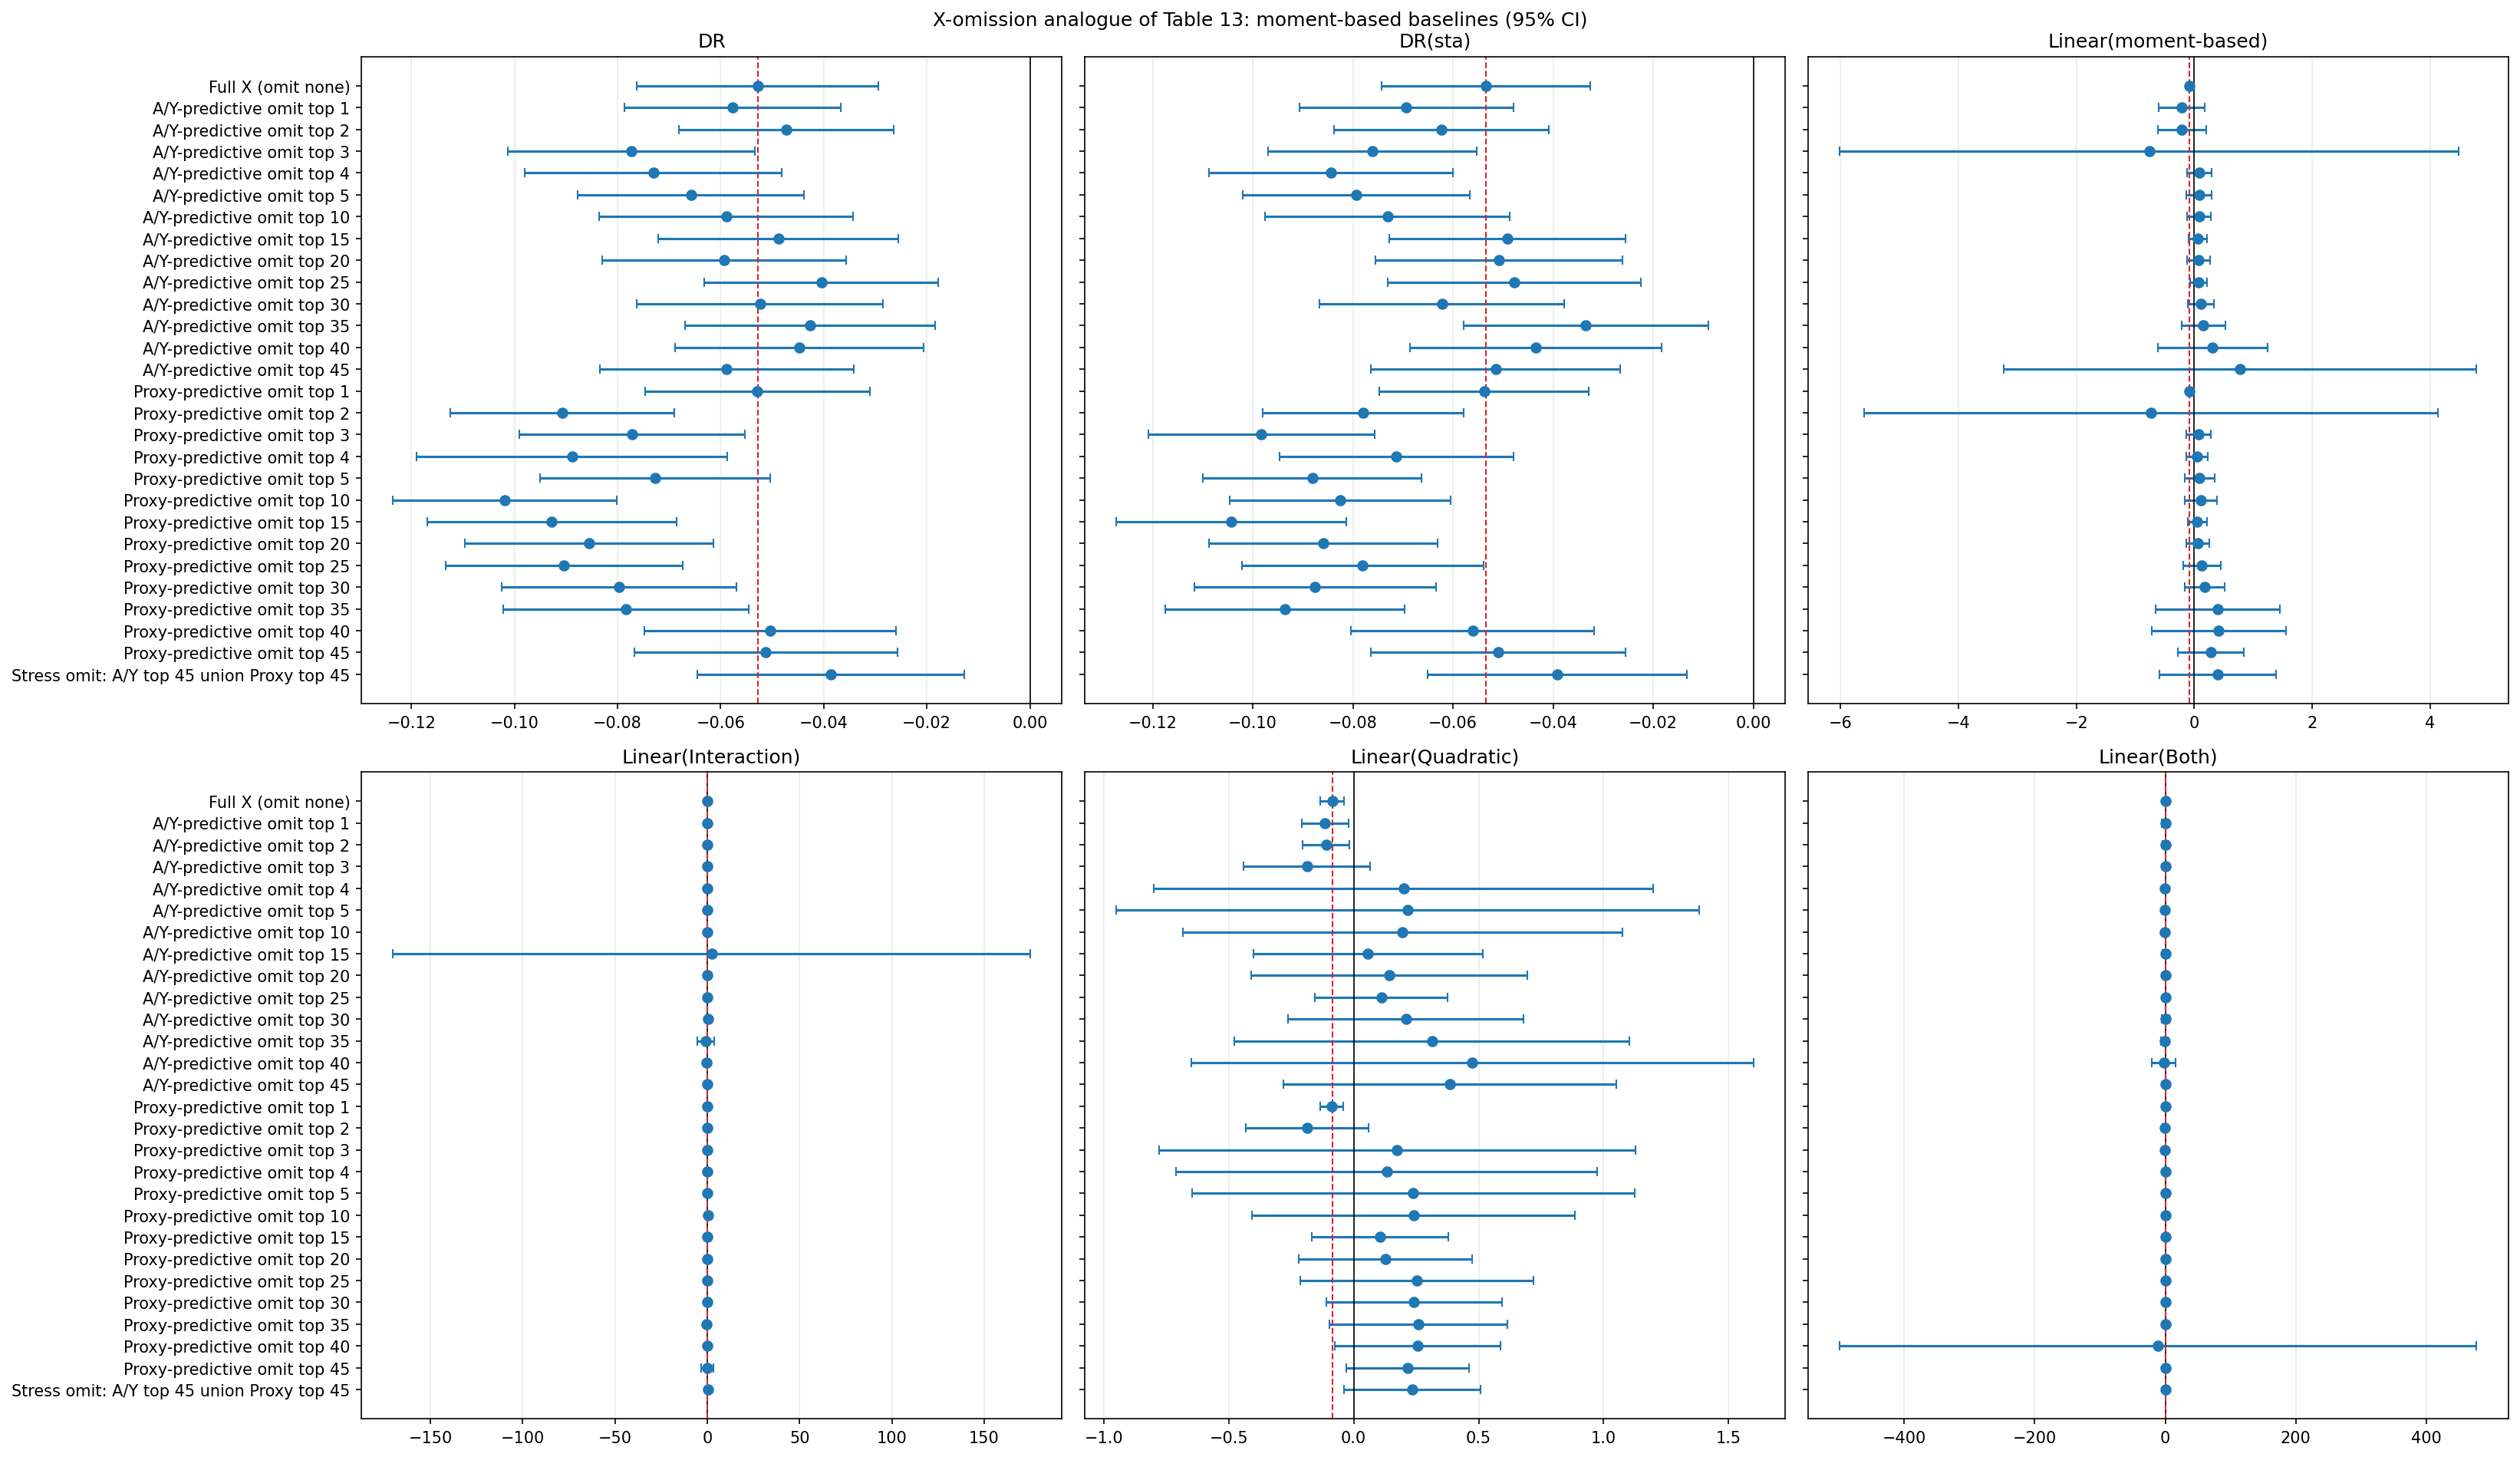

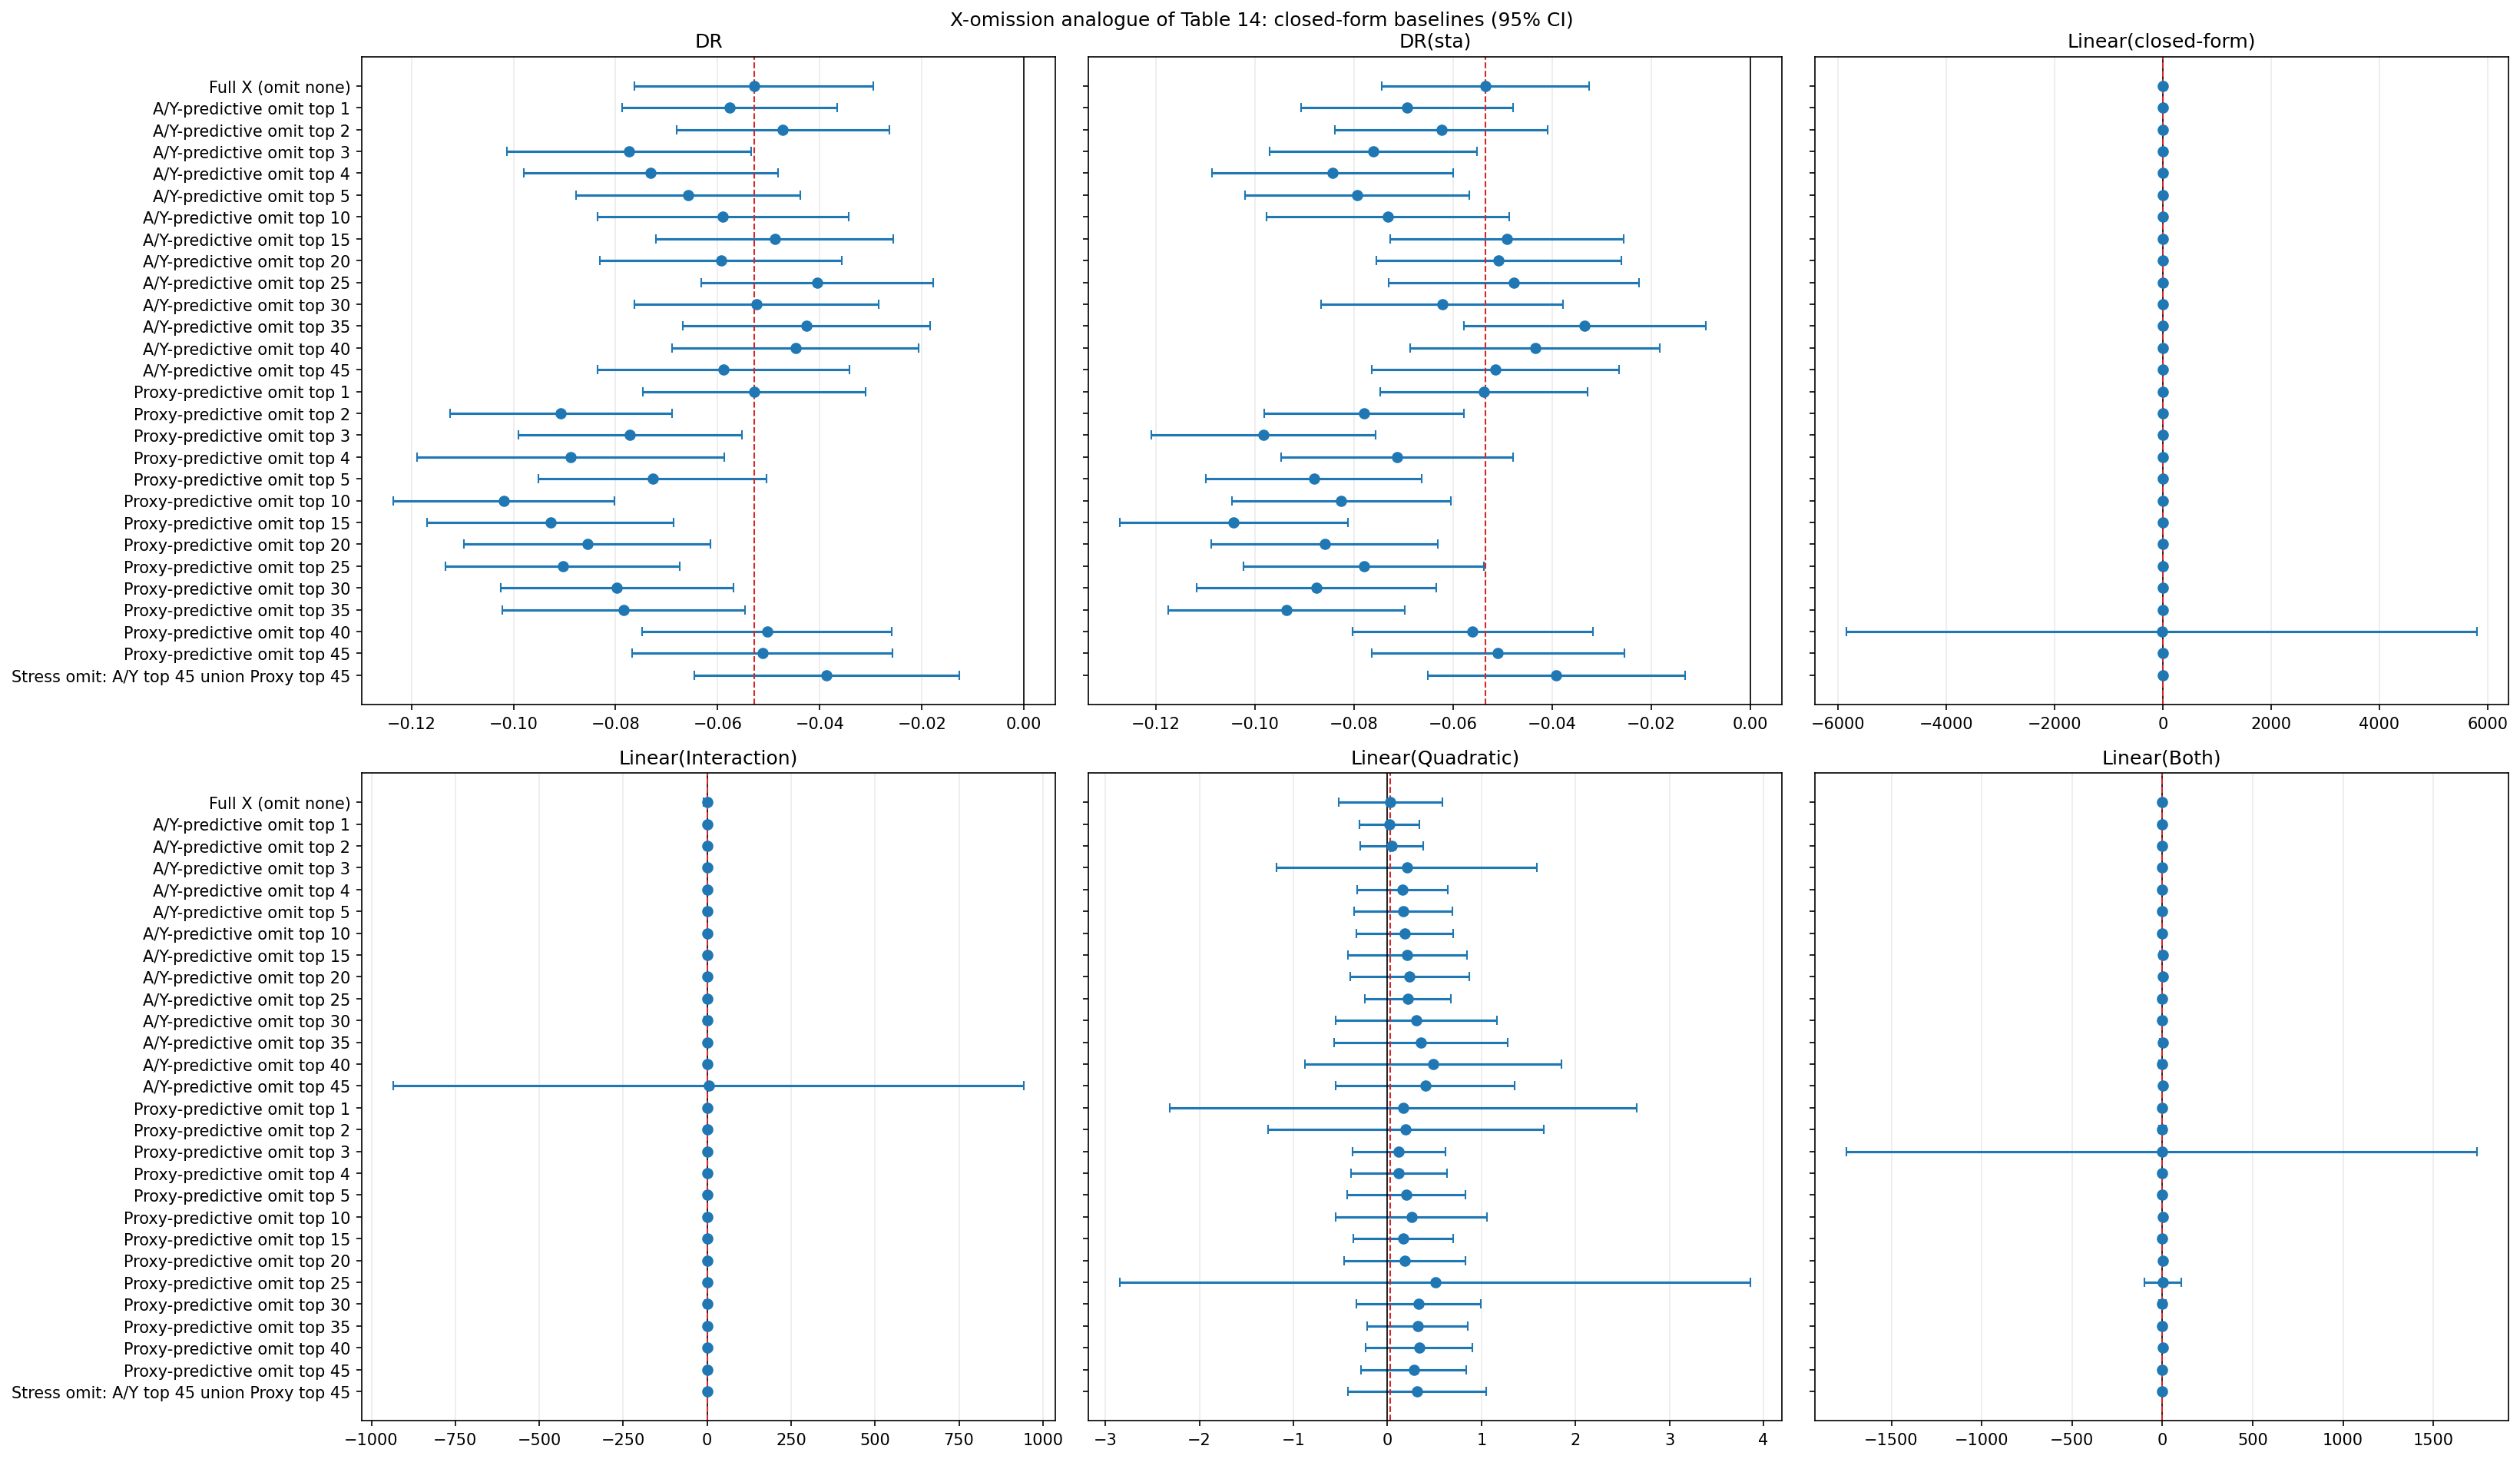

Proposed-method robustness counts:
         Negative point estimates (of 28)  95% CIs below zero (of 28)  Sign agreement with Full X (of 28)  Max |shift|: proxy-predictive  Mean |shift|: proxy-predictive  Max |shift|: all omissions  Mean |shift|: all omissions
DR                                     28                          28                                  28                         0.0490                          0.0257                      0.0490                       0.0174
DR(sta)                                28                          28                                  28                         0.0508                          0.0260                      0.0508                       0.0196

VERIFIED: Table 13/14 method names and panel layouts are aligned; all scenarios used fresh raw-data fits and no cached result was read.


In [7]:

from IPython.display import Image as IPythonImage


def plot_table_aligned(title, columns, values_by_column):
    """Plot all six columns appearing in a Table 13- or Table 14-style output."""
    figure_height = max(10, 0.46 * len(SCENARIOS))
    figure, axes = plt.subplots(2, 3, figsize=(22, figure_height), sharey=True)
    y_positions = np.arange(len(SCENARIOS))
    for axis, method in zip(axes.flat, columns):
        values = values_by_column[method]
        method_points = np.array([value["point"] for value in values])
        errors = 1.96 * np.array([value["se"] for value in values])
        axis.errorbar(method_points, y_positions, xerr=errors, fmt="o", capsize=3)
        axis.axvline(0, color="black", linewidth=0.8)
        axis.axvline(method_points[0], color="tab:red", linestyle="--", linewidth=1)
        axis.set_title(method)
        axis.grid(axis="x", alpha=0.25)
    axes[0, 0].set_yticks(y_positions, list(SCENARIOS))
    axes[0, 0].invert_yaxis()
    figure.suptitle(title)
    figure.tight_layout()
    plot_buffer = io.BytesIO()
    figure.savefig(plot_buffer, format="png", dpi=150, bbox_inches="tight")
    display(IPythonImage(data=plot_buffer.getvalue()))
    plt.close(figure)


plot_table_aligned(
    "X-omission analogue of Table 13: moment-based baselines (95% CI)",
    TABLE13_FIRST_COLUMNS + TABLE13_SECOND_COLUMNS, TABLE13_VALUES,
)
plot_table_aligned(
    "X-omission analogue of Table 14: closed-form baselines (95% CI)",
    TABLE14_FIRST_COLUMNS + TABLE14_SECOND_COLUMNS, TABLE14_VALUES,
)

print("Proposed-method robustness counts:")
print(robustness.loc[["DR", "DR(sta)"]].to_string(float_format=lambda value: f"{value:.4f}"))
print("\nVERIFIED: Table 13/14 method names and panel layouts are aligned; "
      "all scenarios used fresh raw-data fits and no cached result was read.")
